In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset 1
data1 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_01.csv', index_col='Date', parse_dates=True)
data1.head()

,Value
Date,
1980-01-31,102.483571
1980-02-29,99.208478
1980-03-31,103.038042
1980-04-30,107.314548
1980-05-31,98.428432


In [ ]:
# Load Dataset 2
data2 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_02.csv', index_col='Date', parse_dates=True)
data2.head()

,Value
Date,
1980-01-31,54.630888
1980-02-29,59.747484
1980-03-31,43.407964
1980-04-30,53.416049
1980-05-31,47.548390


In [ ]:
# Load Dataset 3
data3 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_03.csv', index_col='Date', parse_dates=True)
data3.head()

,Value
Date,
1980-01-31,53.891805
1980-02-29,54.526661
1980-03-31,56.309758
1980-04-30,57.621931
1980-05-31,49.887723


In [ ]:
# Load Dataset 4
data4 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_04.csv', index_col='Date', parse_dates=True)
data4.head()

,Value
Date,
1980-01-31,51.426532
1980-02-29,61.042403
1980-03-31,61.389870
1980-04-30,58.675862
1980-05-31,51.120654


In [ ]:
# Load Dataset 5
data5 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/classified_ts_05.csv', index_col='Date', parse_dates=True)
data5.head()

,Value
Date,
1980-01-31,80.921924
1980-02-29,91.396150
1980-03-31,95.863945
1980-04-30,118.876877
1980-05-31,105.565531


ETS DECOMPOSITIONS

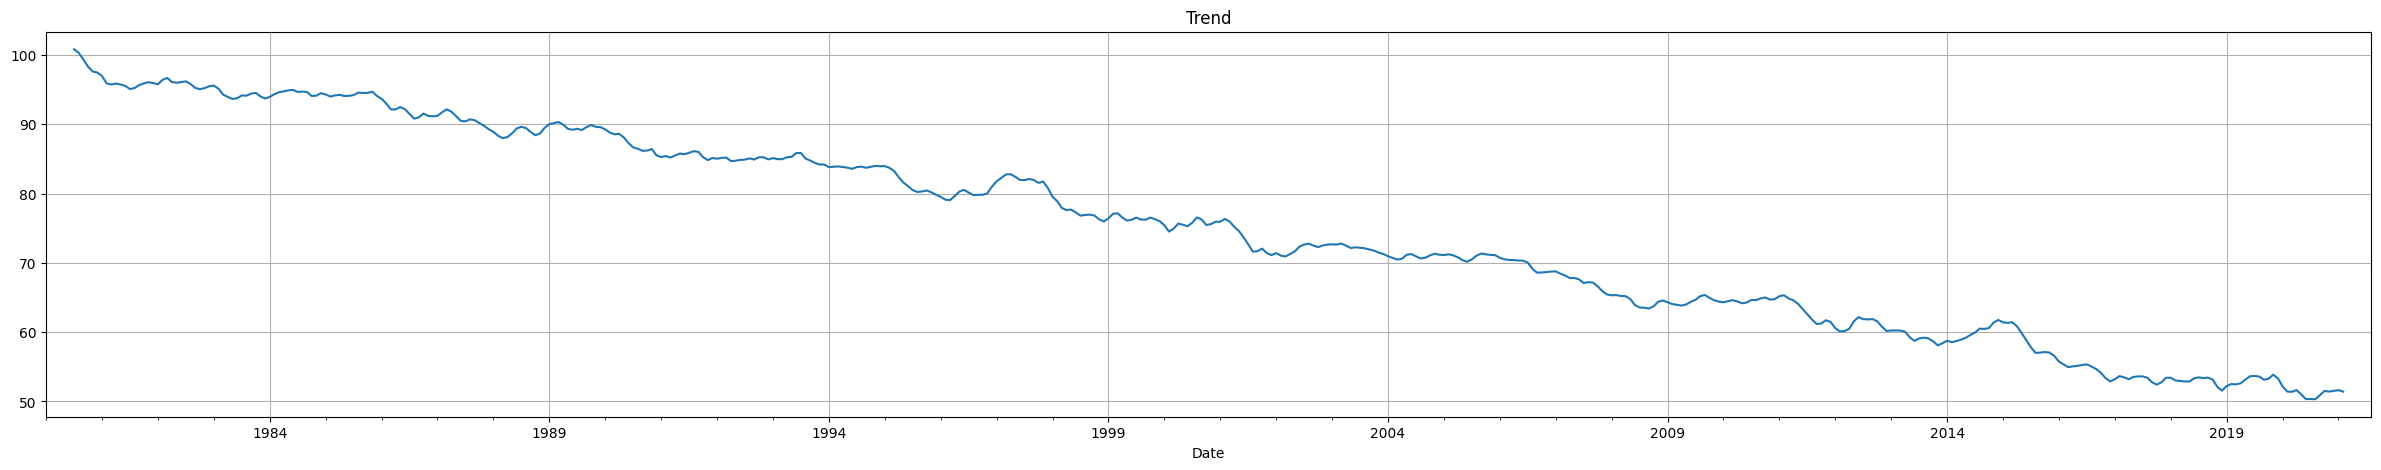

In [ ]:
# Question 1
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition1 = seasonal_decompose(data1['Value'], model='mul')

decomposition1.trend.plot(figsize = (30,5))
plt.title('Trend')
plt.grid()
plt.show()


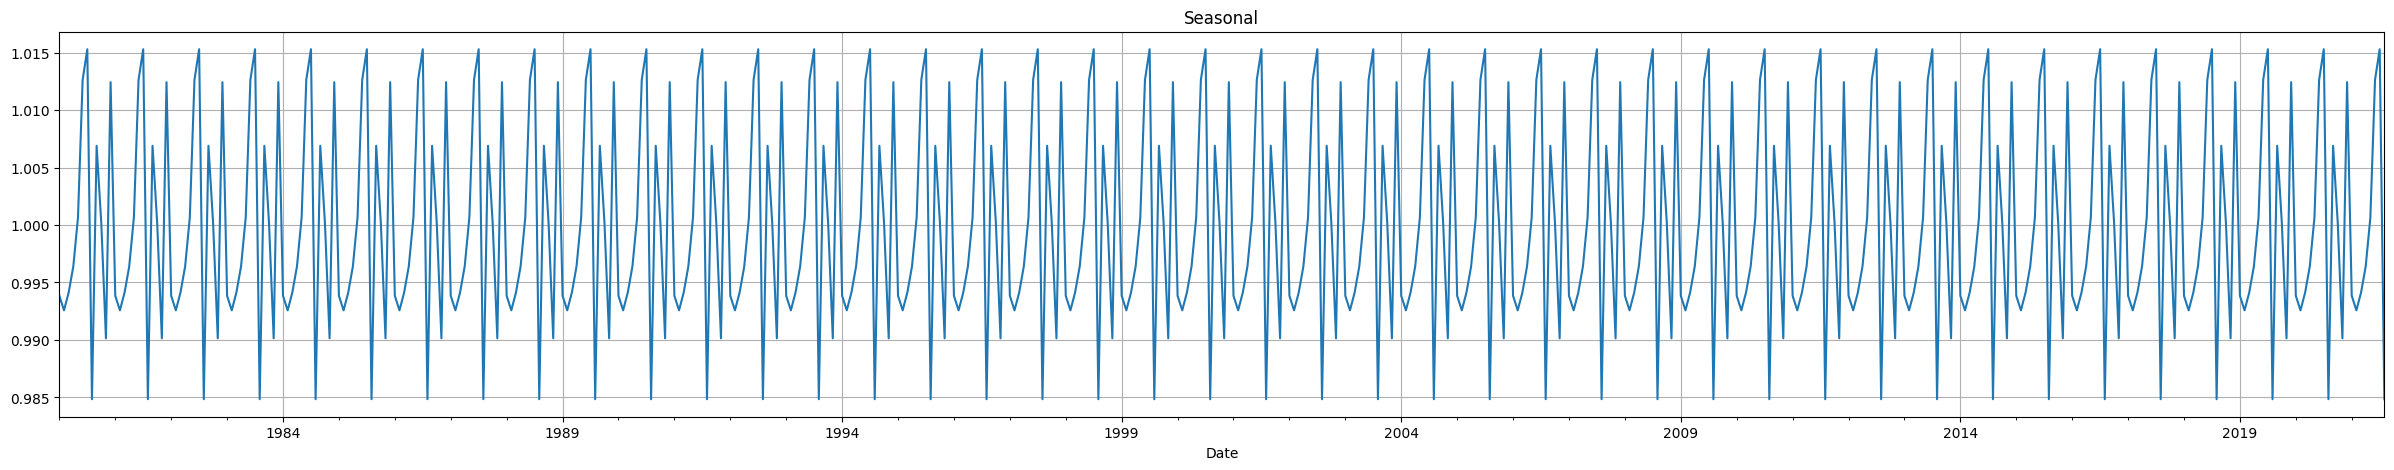

In [ ]:
# Question 2
decomposition1.seasonal.plot(figsize = (30,5))
plt.title('Seasonal')
plt.grid()
plt.show()

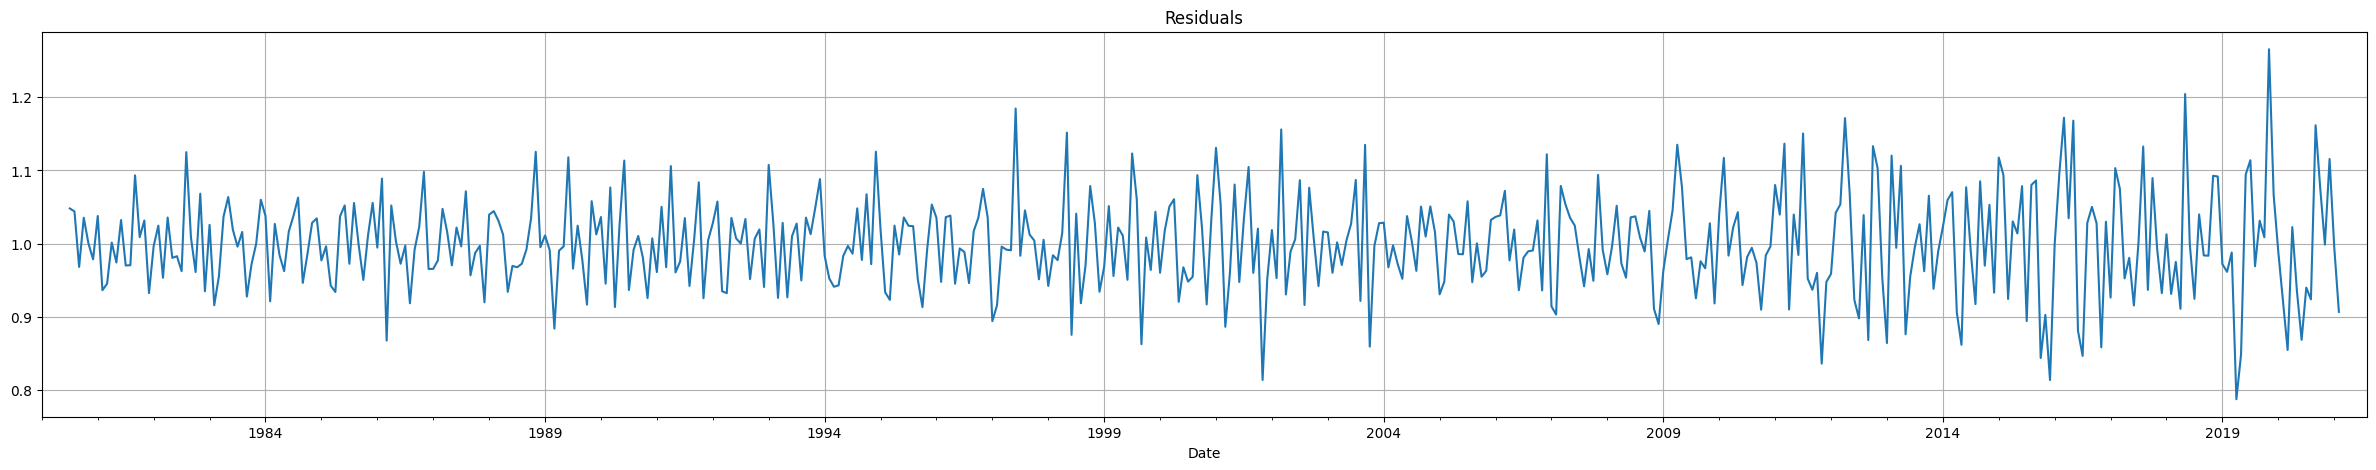

In [ ]:
# Question 3

decomposition1.resid.plot(figsize = (30,5))
plt.title('Residuals')
plt.grid()
plt.show()

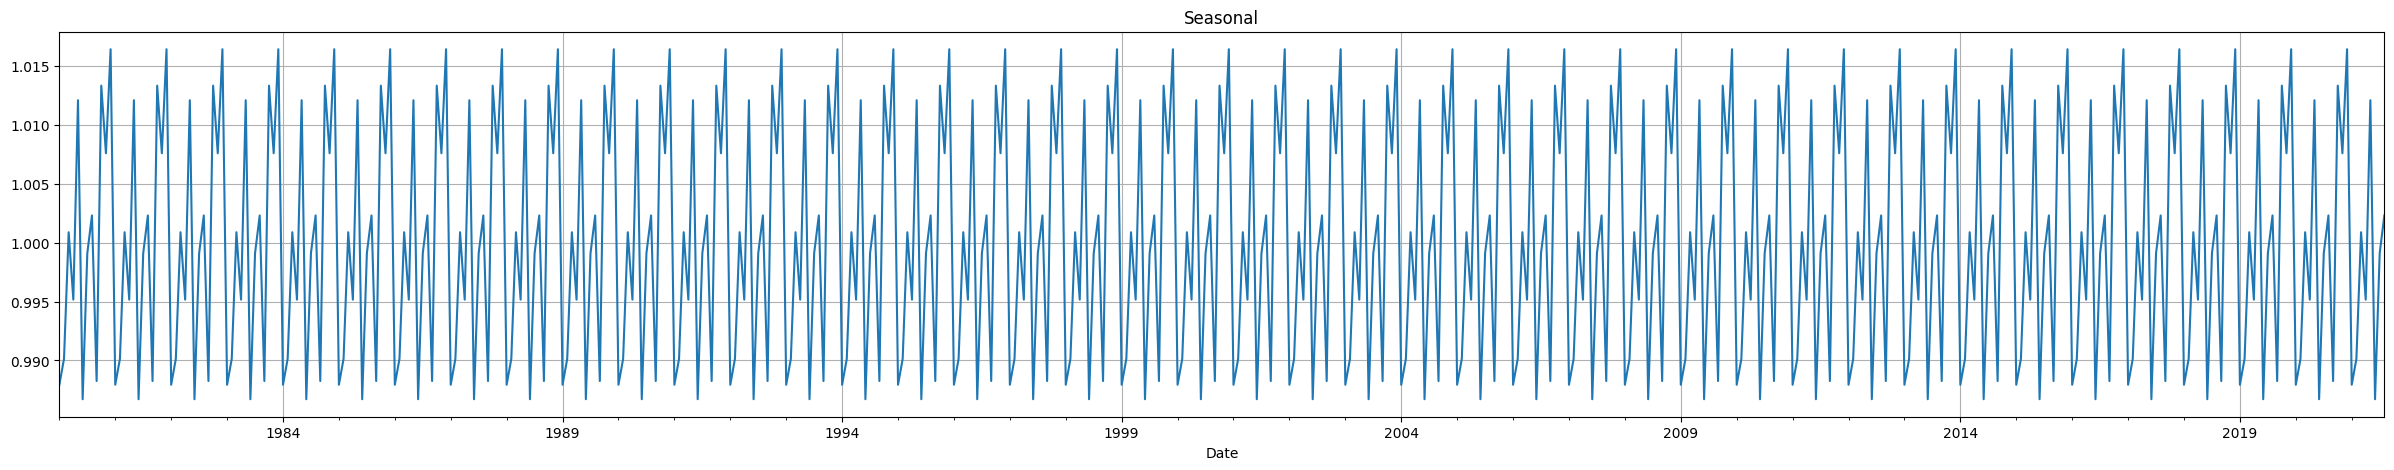

In [ ]:
# Question 4
decomposition1 = seasonal_decompose(data2['Value'], model='mul')

decomposition1.seasonal.plot(figsize = (30,5))
plt.title('Seasonal')
plt.grid()
plt.show()

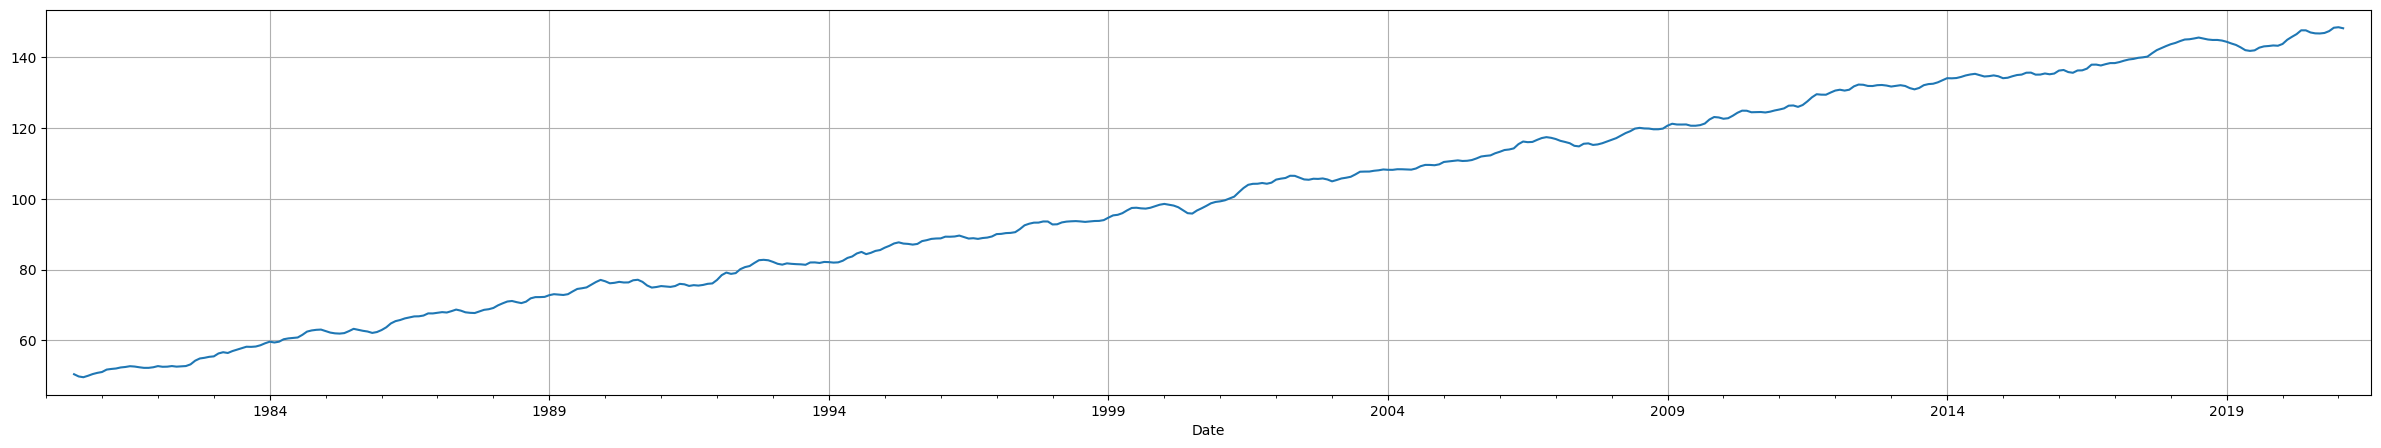

In [ ]:
# Question 5
decomposition1 = seasonal_decompose(data2['Value'], model='mul')

decomposition1.trend.plot(figsize = (30,5))
plt.grid()
plt.show()

STL DECOMPOSITIONS

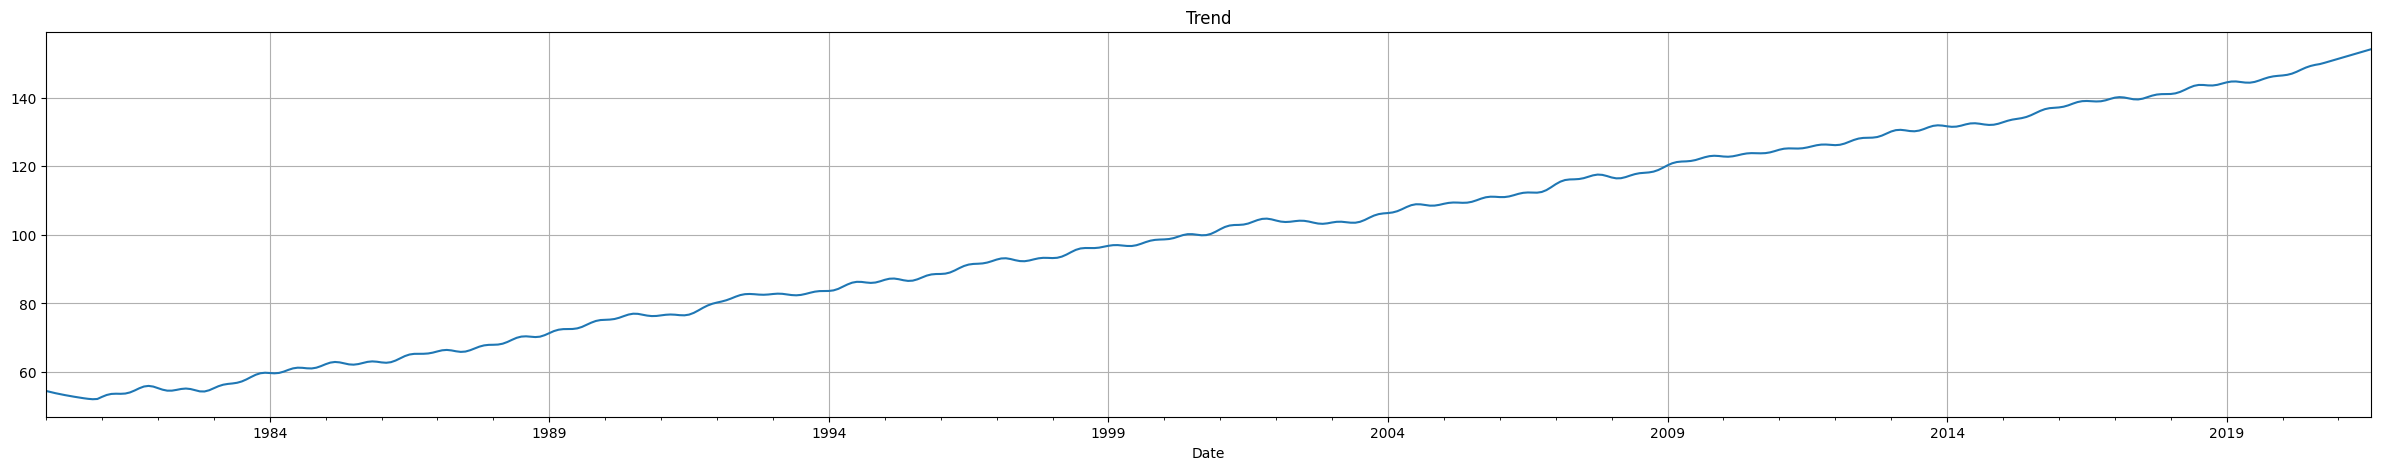

In [ ]:
# Question 6
from statsmodels.tsa.seasonal import STL

stl = STL(data3["Value"], period = 12, robust = True)  # Robust = better handling of outliers
decomp_stl = stl.fit()

decomp_stl.trend.plot(figsize = (30,5))
plt.title('Trend')
plt.grid()
plt.show()

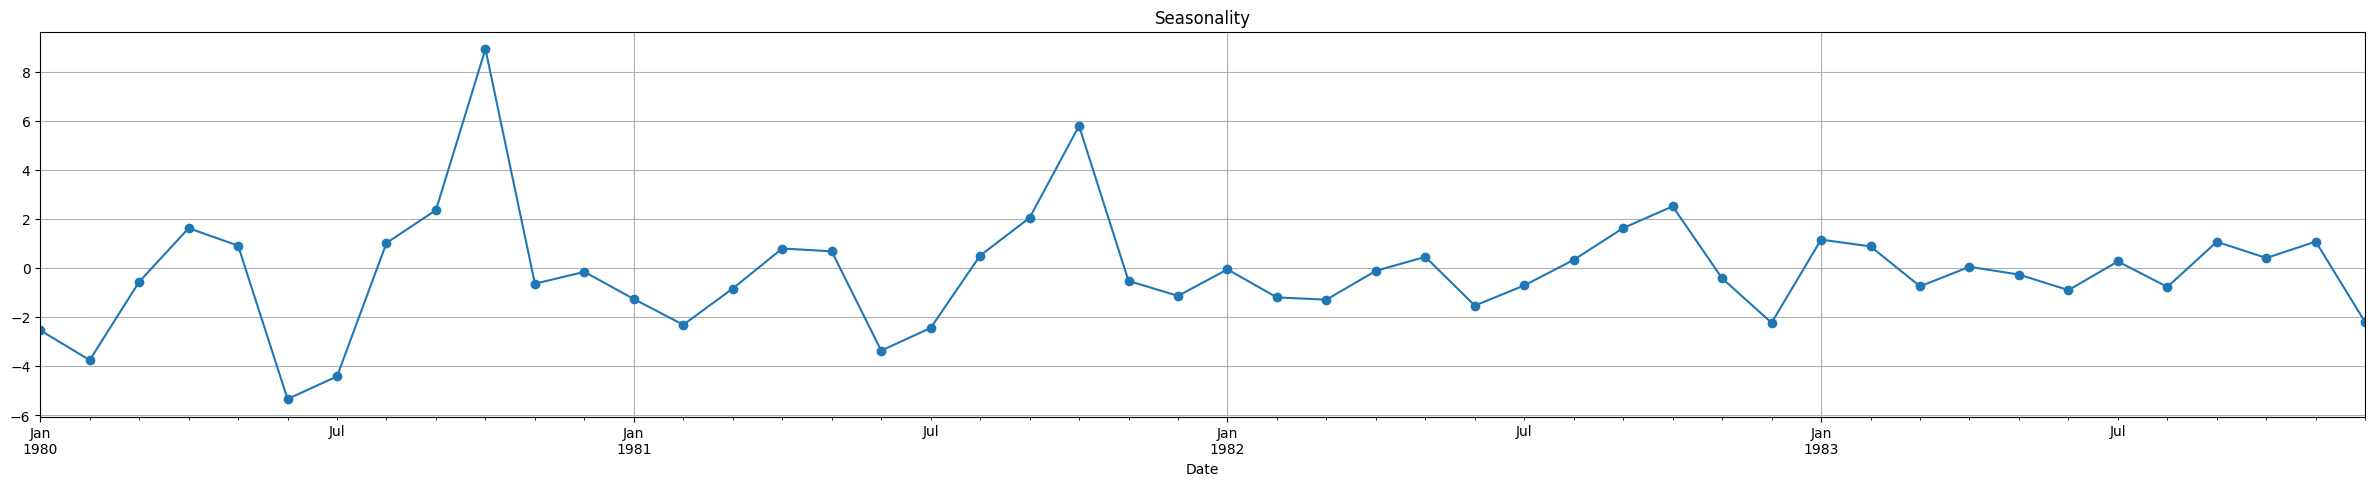

In [ ]:
# Question 7

decomp_stl.seasonal[:48].plot(figsize = (30,5), marker = 'o')
plt.title('Seasonality')
plt.grid()
plt.show()


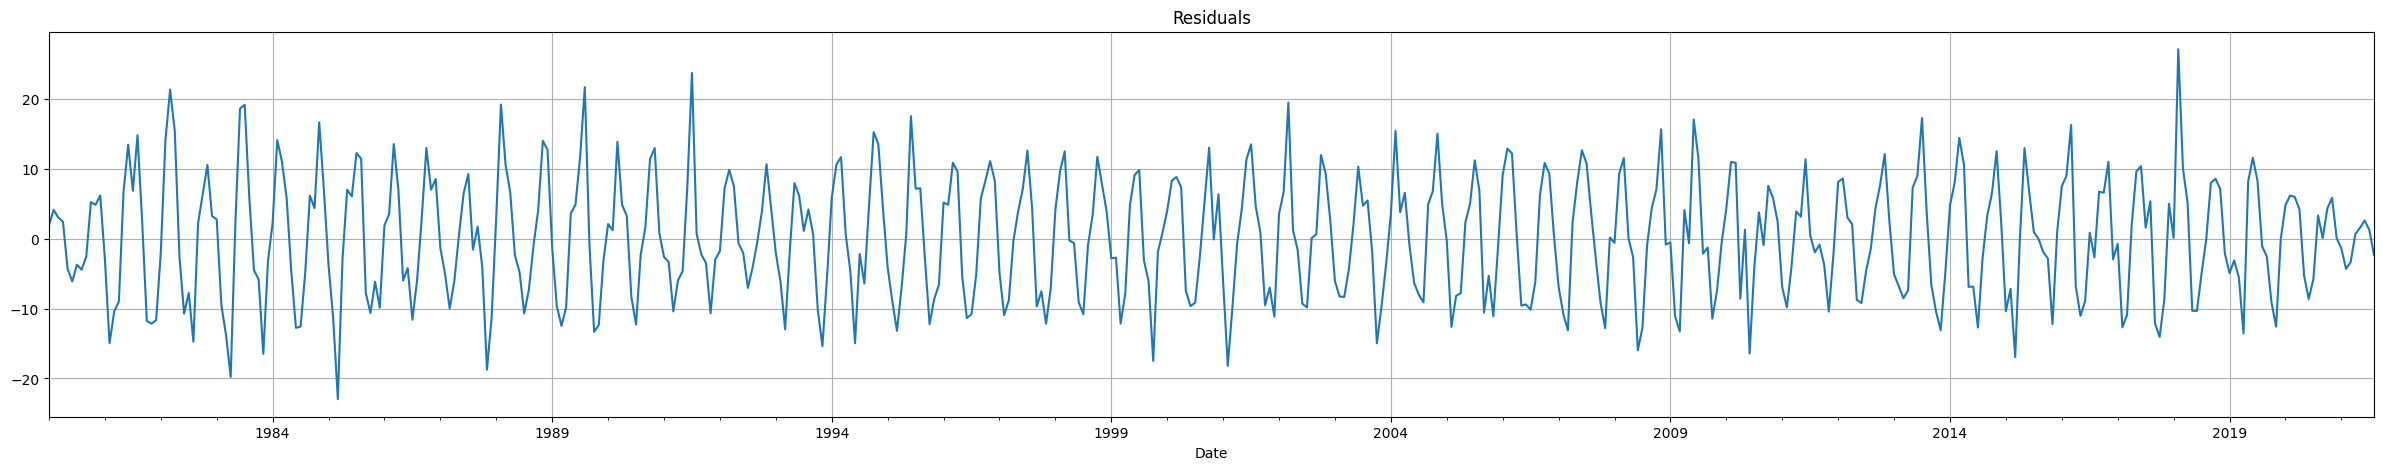

In [ ]:
# Question 8

decomp_stl.resid.plot(figsize = (30,5))
plt.title('Residuals')
plt.grid()
plt.show()


ANY DECOMPOSITION METHOD

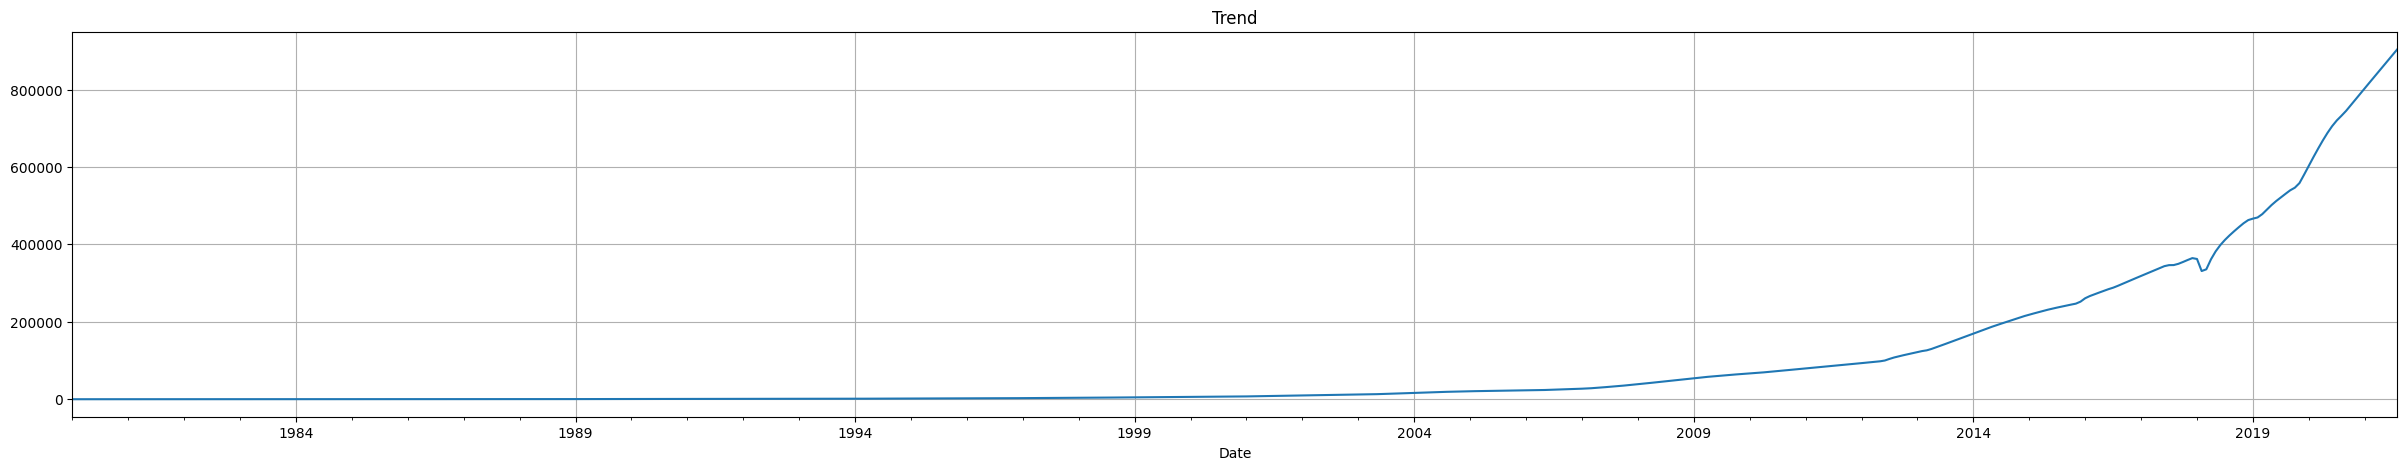

In [ ]:
# Question 9
from statsmodels.tsa.seasonal import STL

stl = STL(data4["Value"], period = 12, robust = True)  # Robust = better handling of outliers
decomp_stl = stl.fit()

decomp_stl.trend.plot(figsize = (30,5))
plt.title('Trend')
plt.grid()
plt.show()


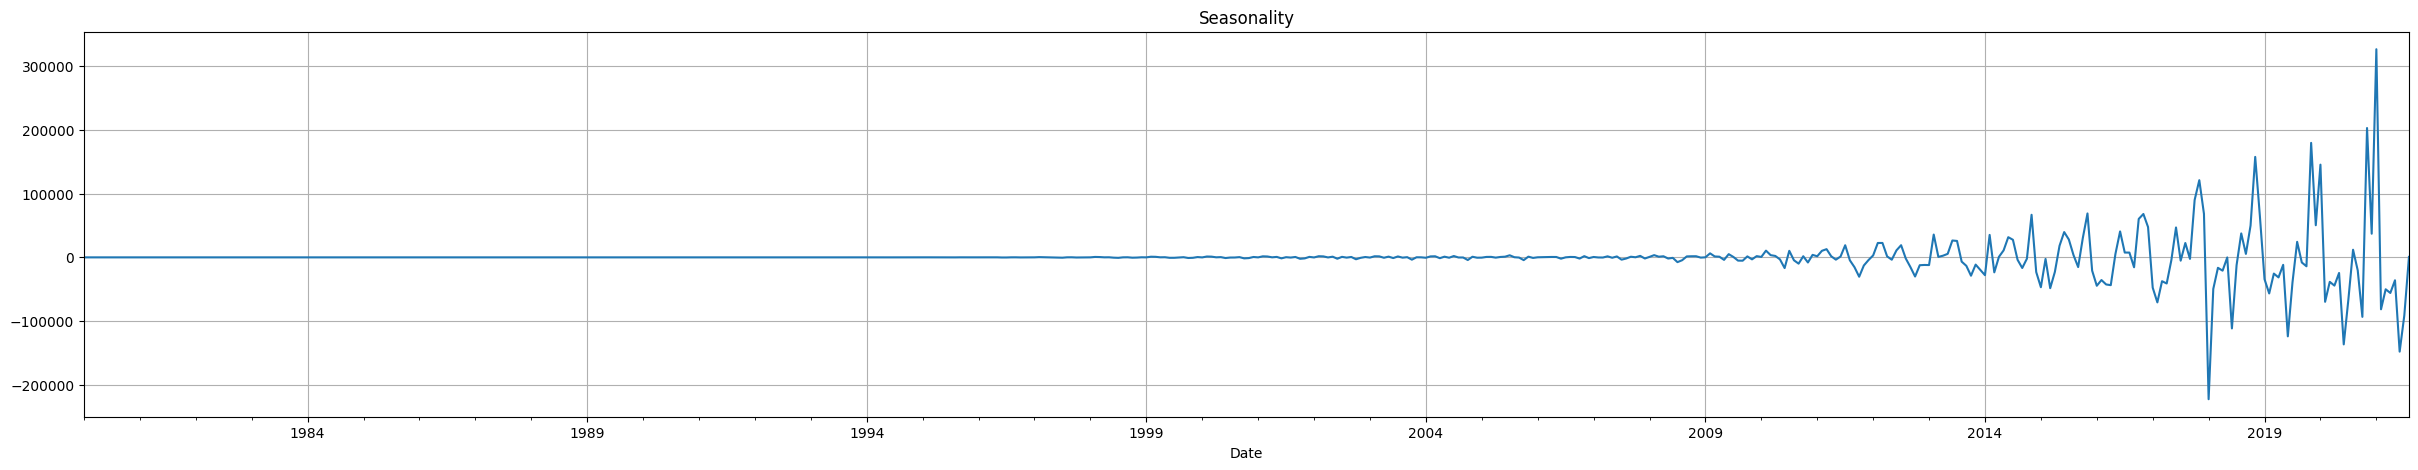

In [ ]:
# Question 10

decomp_stl.seasonal.plot(figsize = (30,5))
plt.title('Seasonality')
plt.grid()
plt.show()

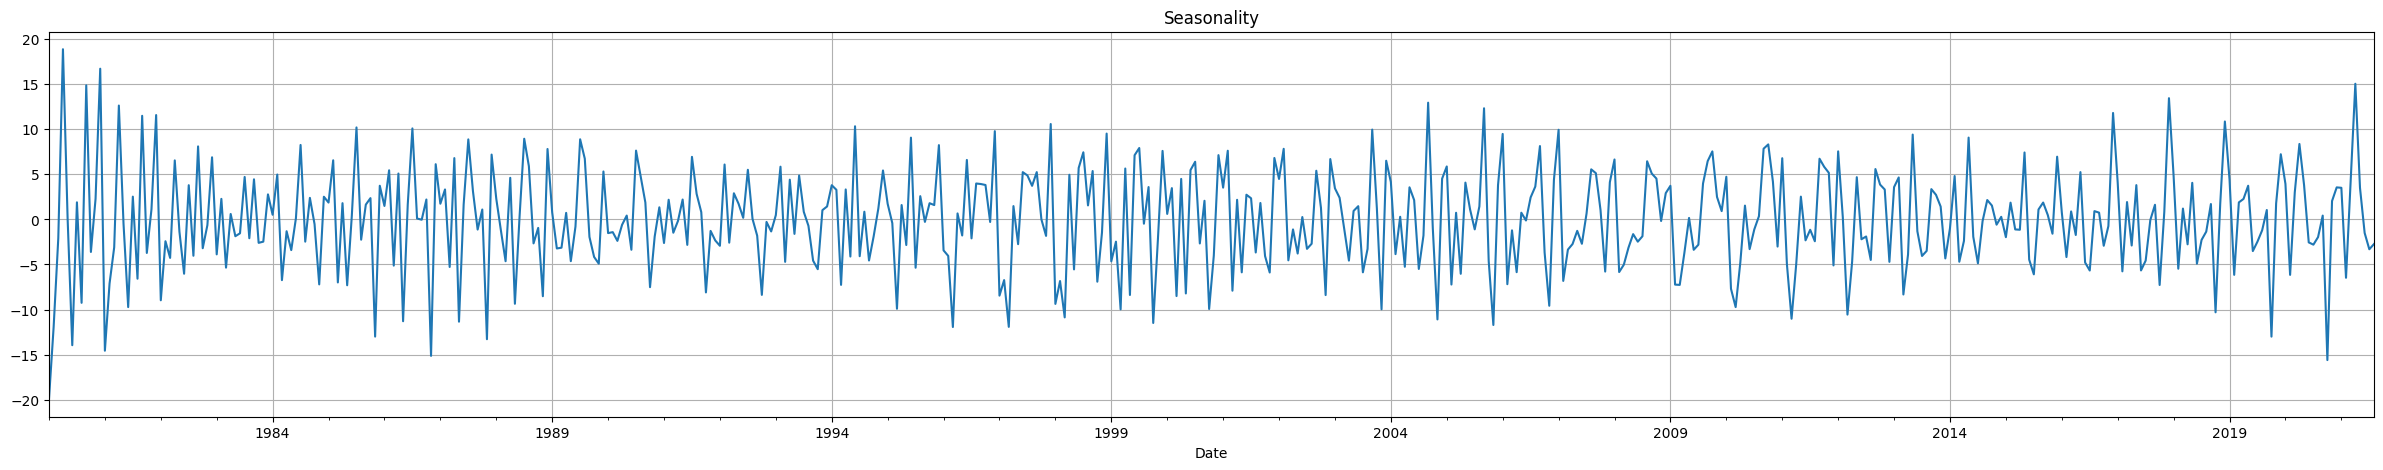

In [ ]:
# Question 11
from statsmodels.tsa.seasonal import STL

stl = STL(data5["Value"], period = 12, robust = True)  # Robust = better handling of outliers
decomp_stl = stl.fit()

decomp_stl.seasonal.plot(figsize = (30,5))
plt.title('Seasonality')
plt.grid()
plt.show()

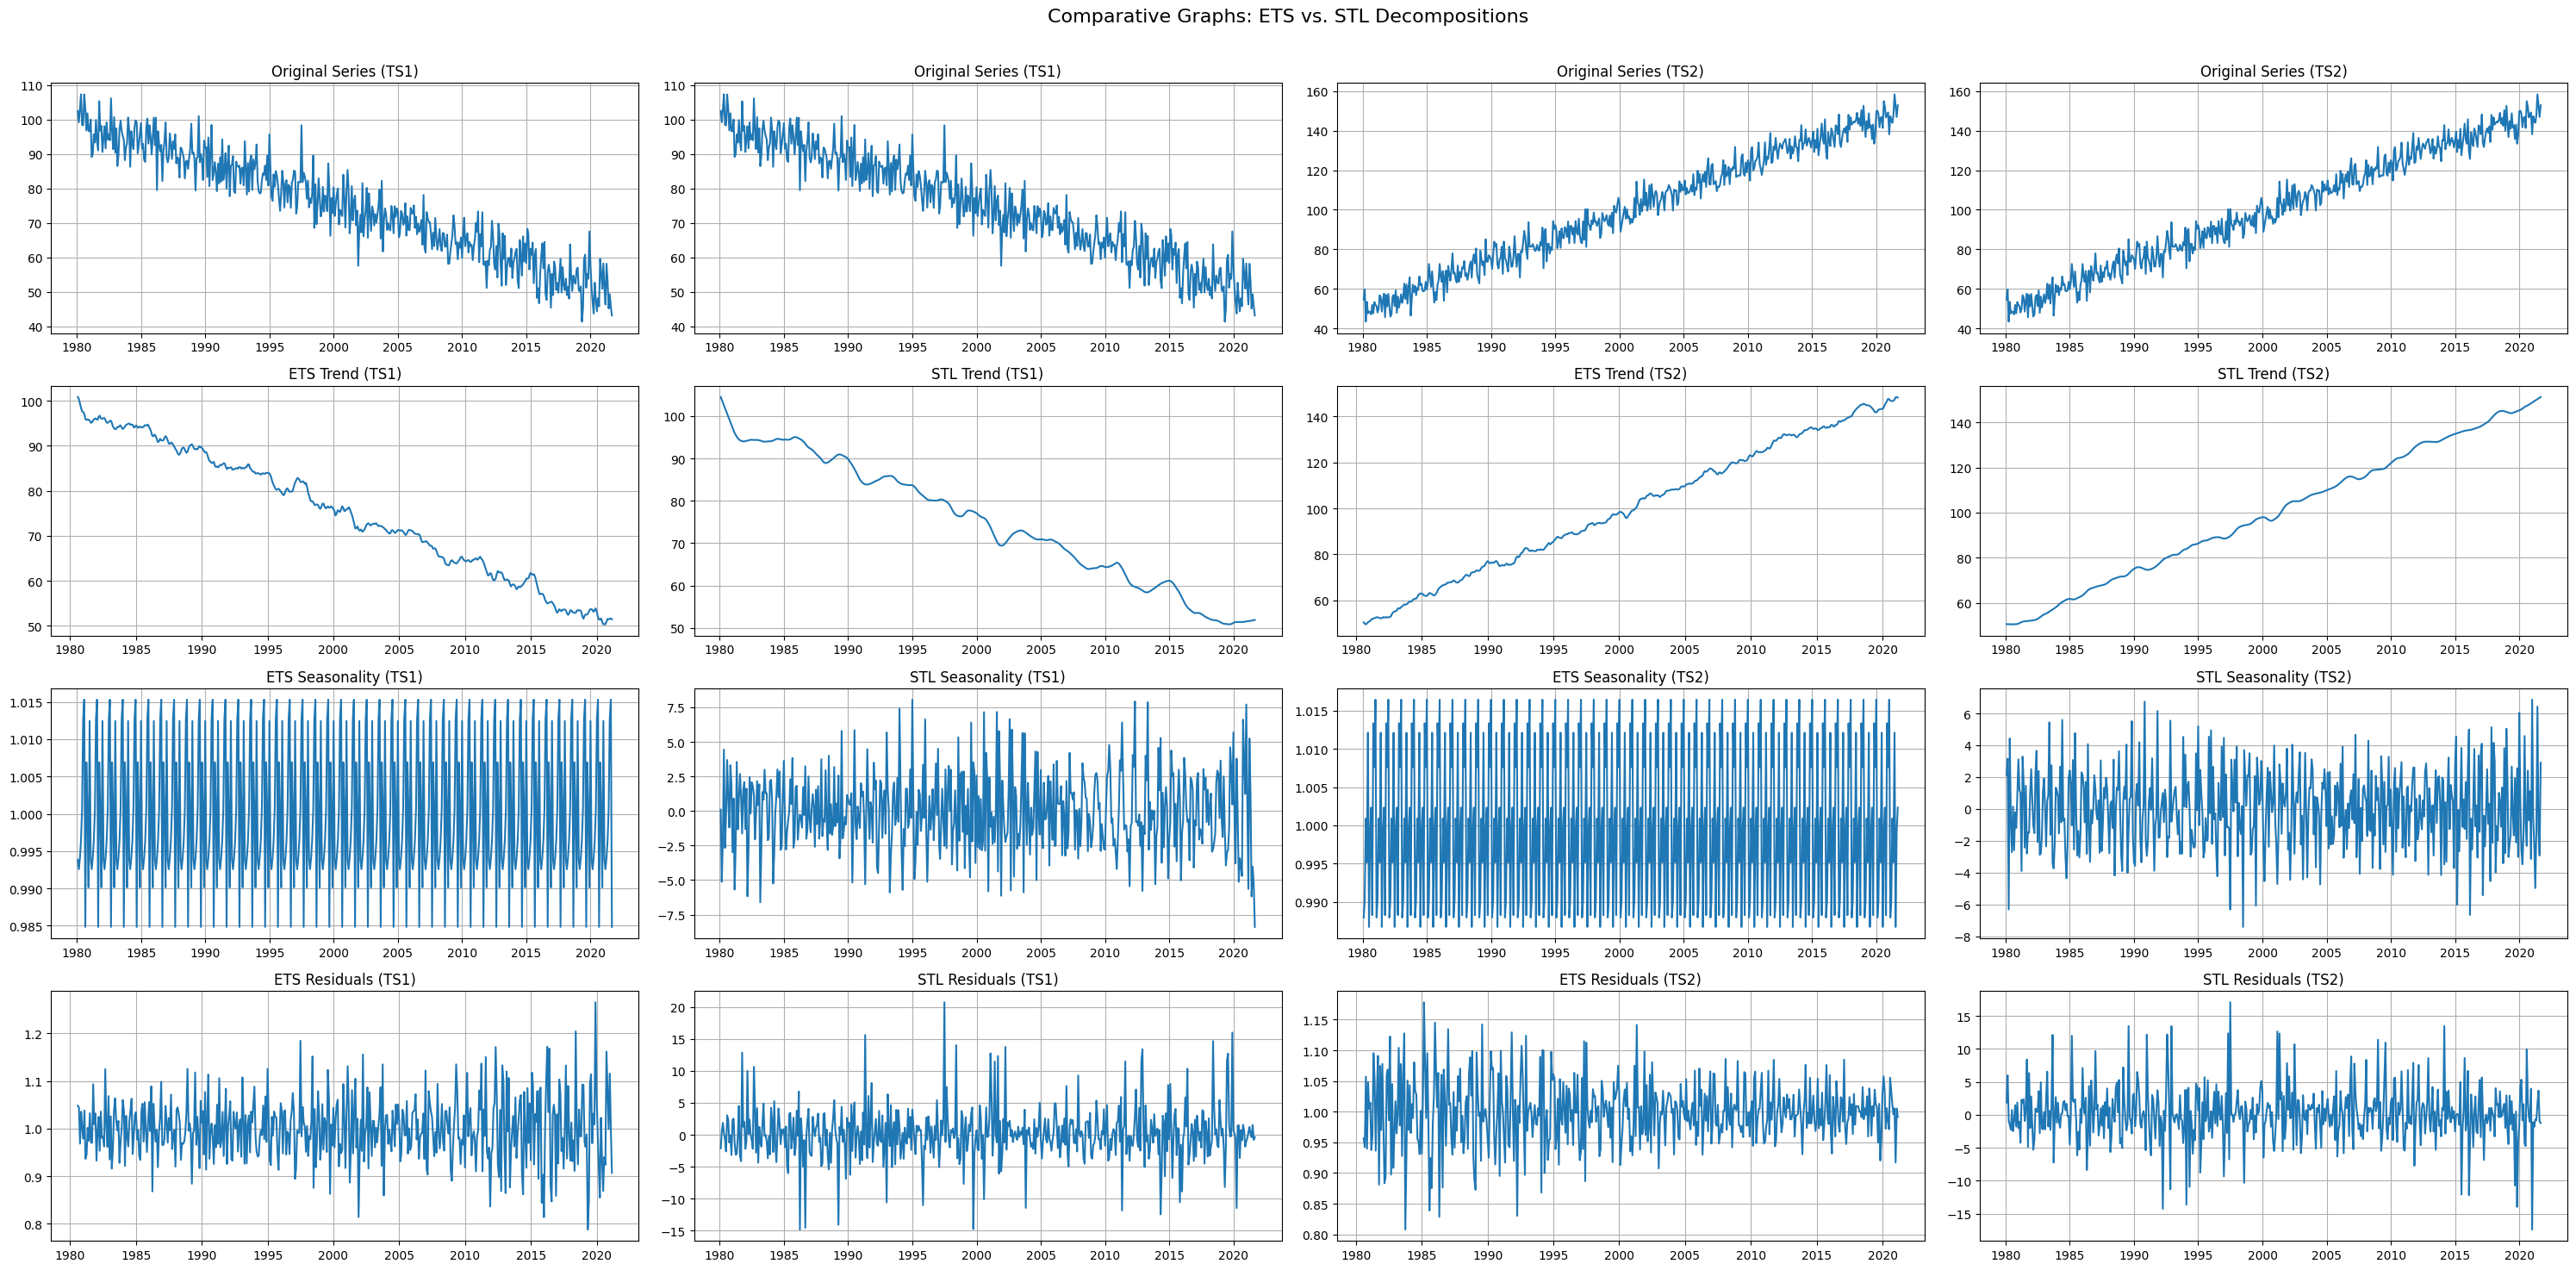

In [ ]:
#Question 12

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# ETS Decomposition
decomp_ets1 = seasonal_decompose(data1["Value"], model="mul", period=12)
decomp_ets2 = seasonal_decompose(data2["Value"], model="mul", period=12)

# STL Decomposition
stl1 = STL(data1["Value"], period=12, robust=True)
decomp_stl1 = stl1.fit()

stl2 = STL(data2["Value"], period=12, robust=True)
decomp_stl2 = stl2.fit()

# Plot ETS and STL Decomposition Side-by-Side
fig, axes = plt.subplots(4, 4, figsize=(30, 15))
fig.suptitle("Comparative Graphs: ETS vs. STL Decompositions", fontsize=16)

# Titles for decomposition components
titles = ["Trend", "Seasonality", "Residuals"]

# Plot Original Series for TS1 and TS2
axes[0, 0].plot(data1["Value"])
axes[0, 0].set_title("Original Series (TS1)")
axes[0, 0].grid()

axes[0, 2].plot(data2["Value"])
axes[0, 2].set_title("Original Series (TS2)")
axes[0, 2].grid()

# Also plot the original series for STL to bring back the missing columns
axes[0, 1].plot(data1["Value"])
axes[0, 1].set_title("Original Series (TS1)")
axes[0, 1].grid()

axes[0, 3].plot(data2["Value"])
axes[0, 3].set_title("Original Series (TS2)")
axes[0, 3].grid()

# Plot ETS Decomposition for TS1
components_ets1 = [decomp_ets1.trend, decomp_ets1.seasonal, decomp_ets1.resid]
for i in range(3):
    axes[i + 1, 0].plot(components_ets1[i])
    axes[i + 1, 0].set_title(f"ETS {titles[i]} (TS1)")
    axes[i + 1, 0].grid()

# Plot ETS Decomposition for TS2
components_ets2 = [decomp_ets2.trend, decomp_ets2.seasonal, decomp_ets2.resid]
for i in range(3):
    axes[i + 1, 2].plot(components_ets2[i])
    axes[i + 1, 2].set_title(f"ETS {titles[i]} (TS2)")
    axes[i + 1, 2].grid()

# Plot STL Decomposition for TS1
components_stl1 = [decomp_stl1.trend, decomp_stl1.seasonal, decomp_stl1.resid]
for i in range(3):
    axes[i + 1, 1].plot(components_stl1[i])
    axes[i + 1, 1].set_title(f"STL {titles[i]} (TS1)")
    axes[i + 1, 1].grid()

# Plot STL Decomposition for TS2
components_stl2 = [decomp_stl2.trend, decomp_stl2.seasonal, decomp_stl2.resid]
for i in range(3):
    axes[i + 1, 3].plot(components_stl2[i])
    axes[i + 1, 3].set_title(f"STL {titles[i]} (TS2)")
    axes[i + 1, 3].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

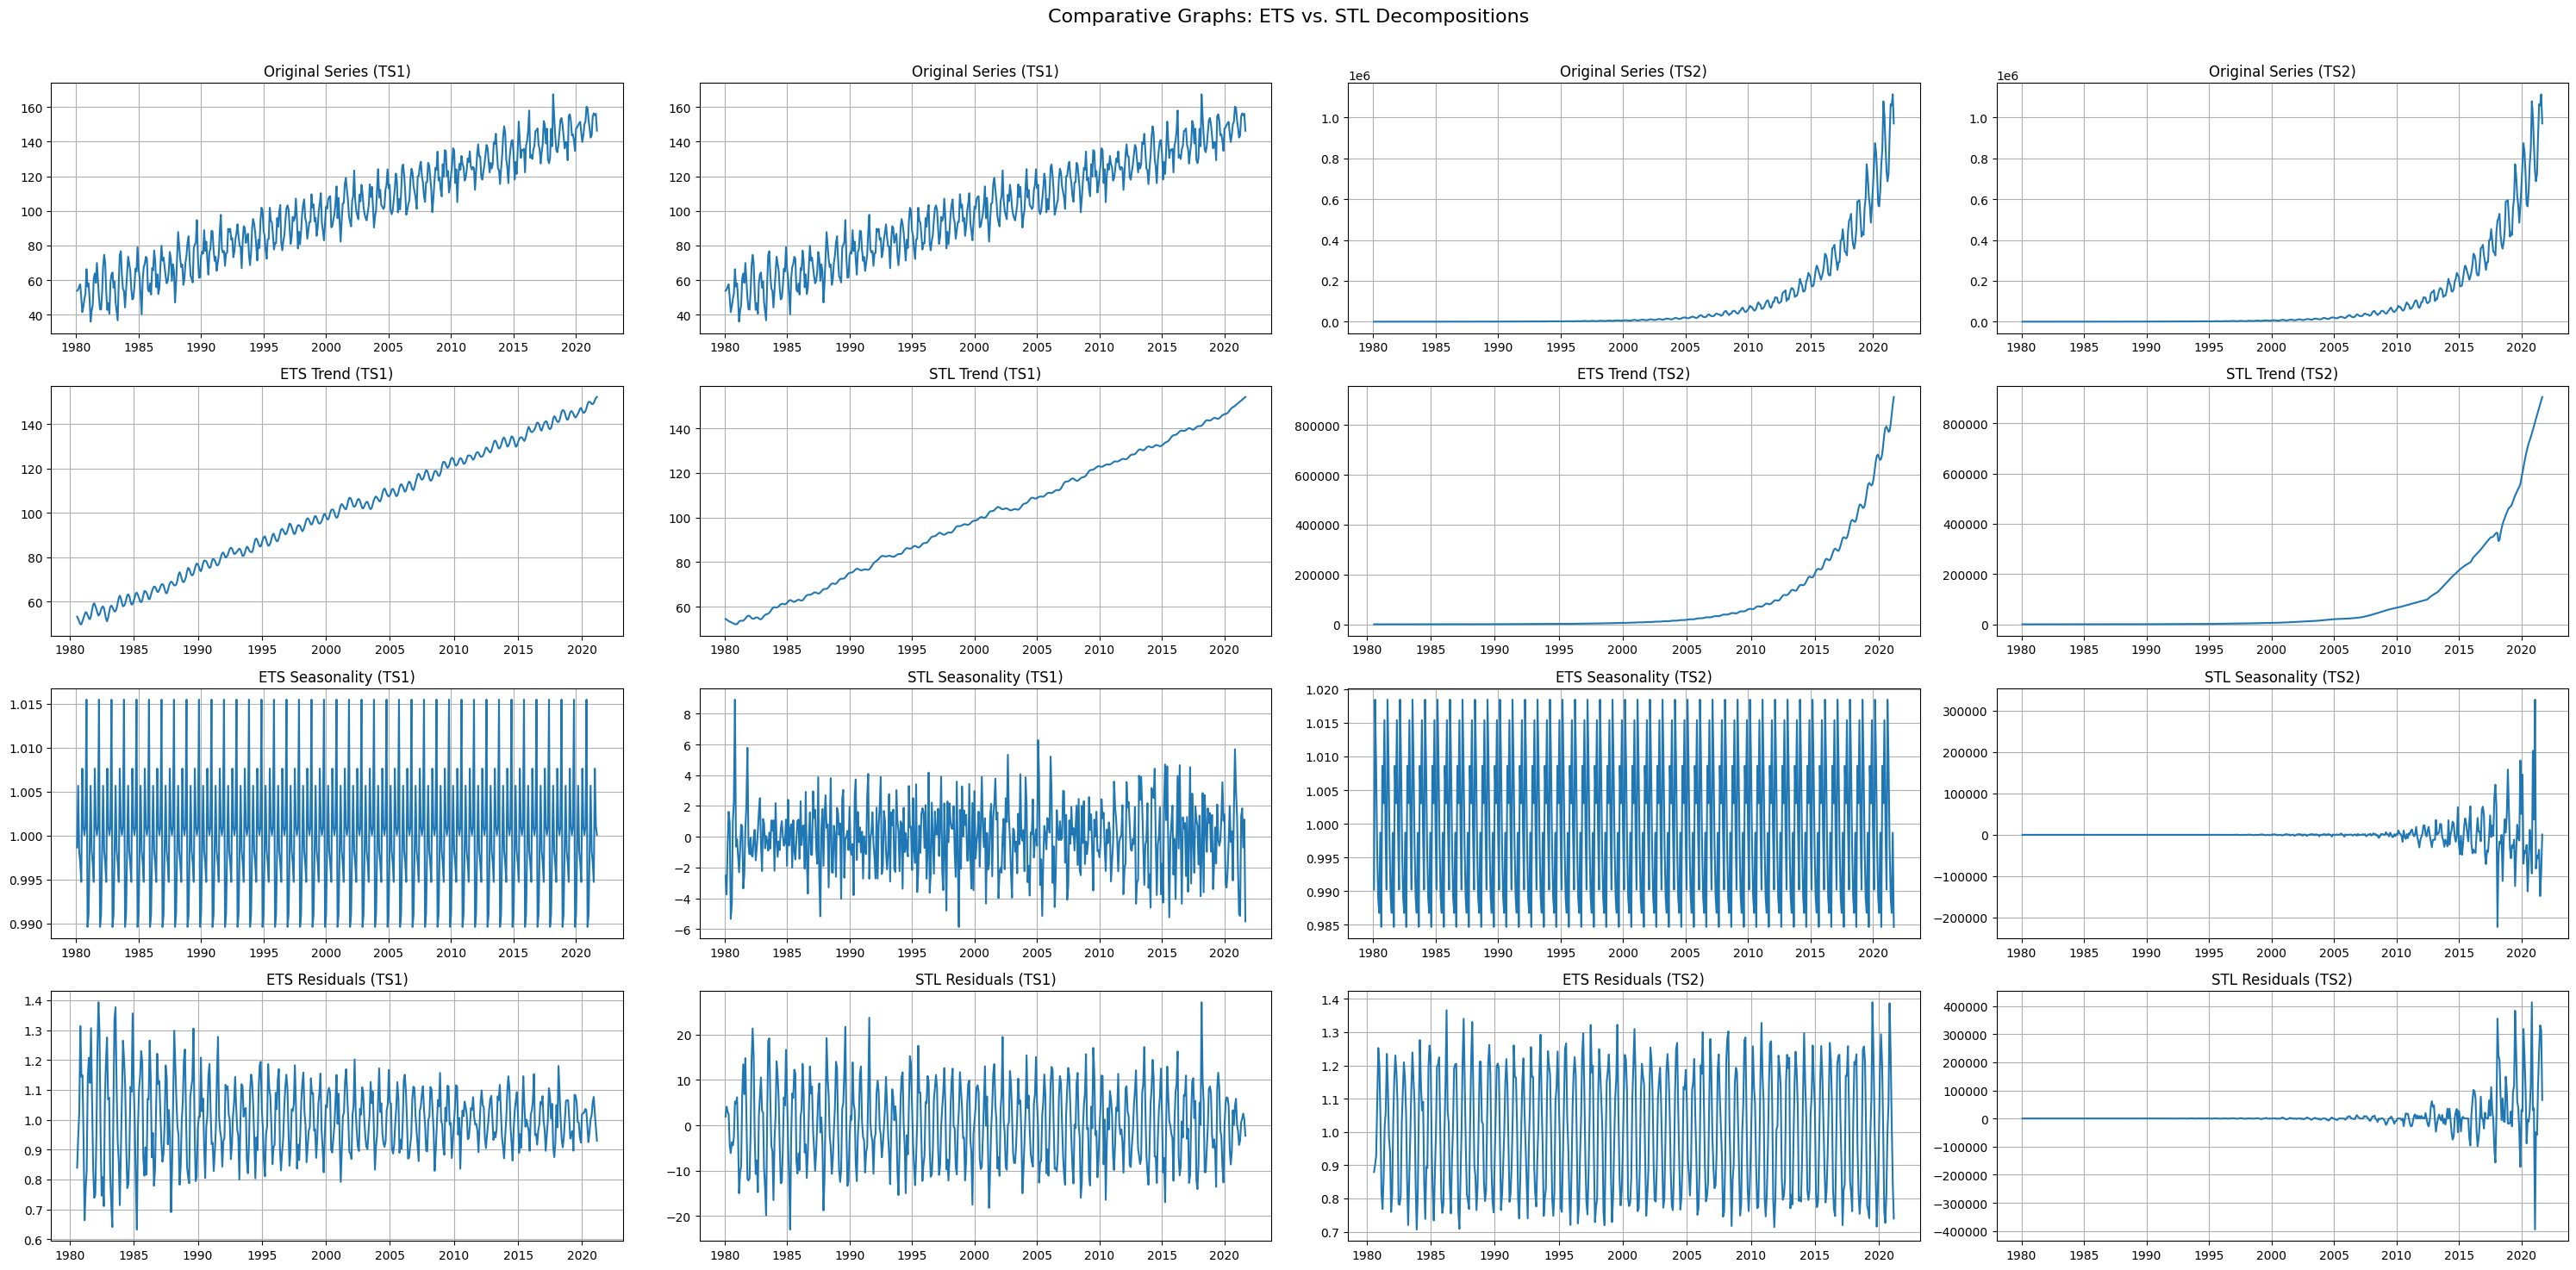

In [ ]:
#Question 13

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# ETS Decomposition
decomp_ets1 = seasonal_decompose(data3["Value"], model="mul", period=12)
decomp_ets2 = seasonal_decompose(data4["Value"], model="mul", period=12)

# STL Decomposition
stl1 = STL(data3["Value"], period=12, robust=True)
decomp_stl1 = stl1.fit()

stl2 = STL(data4["Value"], period=12, robust=True)
decomp_stl2 = stl2.fit()

# Plot ETS and STL Decomposition Side-by-Side
fig, axes = plt.subplots(4, 4, figsize=(30, 15))
fig.suptitle("Comparative Graphs: ETS vs. STL Decompositions", fontsize=16)

# Titles for decomposition components
titles = ["Trend", "Seasonality", "Residuals"]

# Plot Original Series for TS1 and TS2
axes[0, 0].plot(data3["Value"])
axes[0, 0].set_title("Original Series (TS1)")
axes[0, 0].grid()

axes[0, 2].plot(data4["Value"])
axes[0, 2].set_title("Original Series (TS2)")
axes[0, 2].grid()

# Also plot the original series for STL to bring back the missing columns
axes[0, 1].plot(data3["Value"])
axes[0, 1].set_title("Original Series (TS1)")
axes[0, 1].grid()

axes[0, 3].plot(data4["Value"])
axes[0, 3].set_title("Original Series (TS2)")
axes[0, 3].grid()

# Plot ETS Decomposition for TS1
components_ets1 = [decomp_ets1.trend, decomp_ets1.seasonal, decomp_ets1.resid]
for i in range(3):
    axes[i + 1, 0].plot(components_ets1[i])
    axes[i + 1, 0].set_title(f"ETS {titles[i]} (TS1)")
    axes[i + 1, 0].grid()

# Plot ETS Decomposition for TS2
components_ets2 = [decomp_ets2.trend, decomp_ets2.seasonal, decomp_ets2.resid]
for i in range(3):
    axes[i + 1, 2].plot(components_ets2[i])
    axes[i + 1, 2].set_title(f"ETS {titles[i]} (TS2)")
    axes[i + 1, 2].grid()

# Plot STL Decomposition for TS1
components_stl1 = [decomp_stl1.trend, decomp_stl1.seasonal, decomp_stl1.resid]
for i in range(3):
    axes[i + 1, 1].plot(components_stl1[i])
    axes[i + 1, 1].set_title(f"STL {titles[i]} (TS1)")
    axes[i + 1, 1].grid()

# Plot STL Decomposition for TS2
components_stl2 = [decomp_stl2.trend, decomp_stl2.seasonal, decomp_stl2.resid]
for i in range(3):
    axes[i + 1, 3].plot(components_stl2[i])
    axes[i + 1, 3].set_title(f"STL {titles[i]} (TS2)")
    axes[i + 1, 3].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()